# Car Market Analysis – Car Dekho Data

## Project Objective
Analyze historical used-car data to understand pricing patterns and the factors associated with selling price.

**Technology:** Python, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook.

### Business Questions
- What is the distribution of used-car selling prices?
- How does manufacturing year relate to selling price?
- How do fuel type, transmission and seller type differ in average price?
- Does higher mileage relate to lower selling price?
- Which numerical variables have the strongest association with selling price?
- What practical insights can support buyers, sellers and dealers?

This notebook follows the supplied Car Market Analysis project brief.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = pd.read_csv("Car Market Trends Analysis with Car Dekho Data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 1. Dataset Overview

In [2]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_values"))

print("\nDuplicate rows:", df.duplicated().sum())

display(df.describe(include="all").T)

Dataset shape: (301, 9)

Columns:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

Data types:


,dtype
Car_Name,object
Year,int64
Selling_Price,float64
Present_Price,float64
Kms_Driven,int64
Fuel_Type,object
Seller_Type,object
Transmission,object
Owner,int64



Missing values:


,missing_values
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0



Duplicate rows: 2


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.00,NaN,NaN,NaN,"2,013.63",2.89,"2,003.00","2,012.00","2,014.00","2,016.00","2,018.00"
Selling_Price,301.00,NaN,NaN,NaN,4.66,5.08,0.10,0.90,3.60,6.00,35.00
Present_Price,301.00,NaN,NaN,NaN,7.63,8.64,0.32,1.20,6.40,9.90,92.60
Kms_Driven,301.00,NaN,NaN,NaN,"36,947.21","38,886.88",500.00,"15,000.00","32,000.00","48,767.00","500,000.00"
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seller_Type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.00,NaN,NaN,NaN,0.04,0.25,0.00,0.00,0.00,0.00,3.00


## 2. Data Cleaning & Feature Engineering

In [3]:
data = df.copy()

# Standardize categorical values
for col in ["Car_Name", "Fuel_Type", "Seller_Type", "Transmission"]:
    data[col] = data[col].astype(str).str.strip()

# Remove exact duplicate rows
data = data.drop_duplicates().reset_index(drop=True)

# Reference year is one year after the latest manufacturing year in the supplied data
analysis_year = int(data["Year"].max()) + 1

# New analytical features
data["Car_Age"] = analysis_year - data["Year"]
data["Price_Retention_%"] = (data["Selling_Price"] / data["Present_Price"]) * 100
data["Depreciation_%"] = (1 - data["Selling_Price"] / data["Present_Price"]) * 100

print("Rows after cleaning:", len(data))
display(data.head())

Rows after cleaning: 299


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Price_Retention_%,Depreciation_%
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,5,59.93,40.07
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,6,49.79,50.21
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,2,73.60,26.40
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,8,68.67,31.33
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,5,66.96,33.04


## 3. Selling Price Distribution

Mean selling price: 4.59
Median selling price: 3.51
Minimum selling price: 0.1
Maximum selling price: 35.0


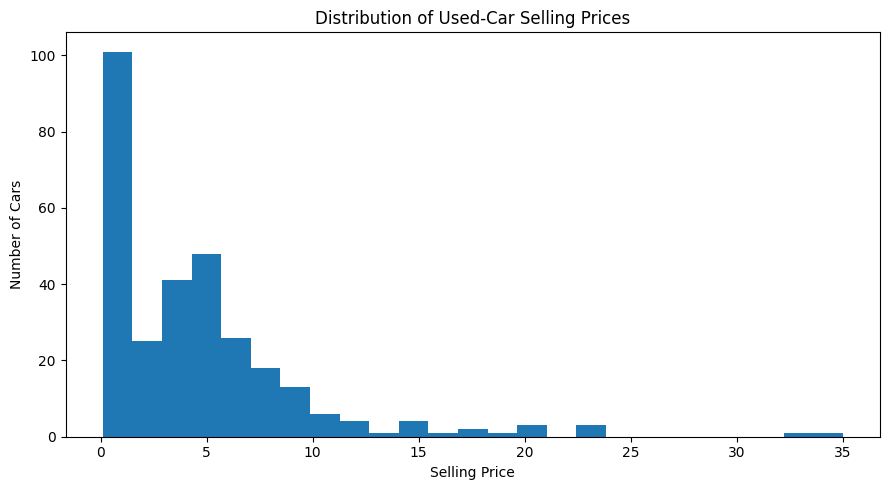

In [4]:
print("Mean selling price:", round(data["Selling_Price"].mean(), 2))
print("Median selling price:", round(data["Selling_Price"].median(), 2))
print("Minimum selling price:", round(data["Selling_Price"].min(), 2))
print("Maximum selling price:", round(data["Selling_Price"].max(), 2))

plt.figure(figsize=(9, 5))
plt.hist(data["Selling_Price"], bins=25)
plt.title("Distribution of Used-Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.tight_layout()
plt.show()

## 4. Manufacturing Year vs Selling Price

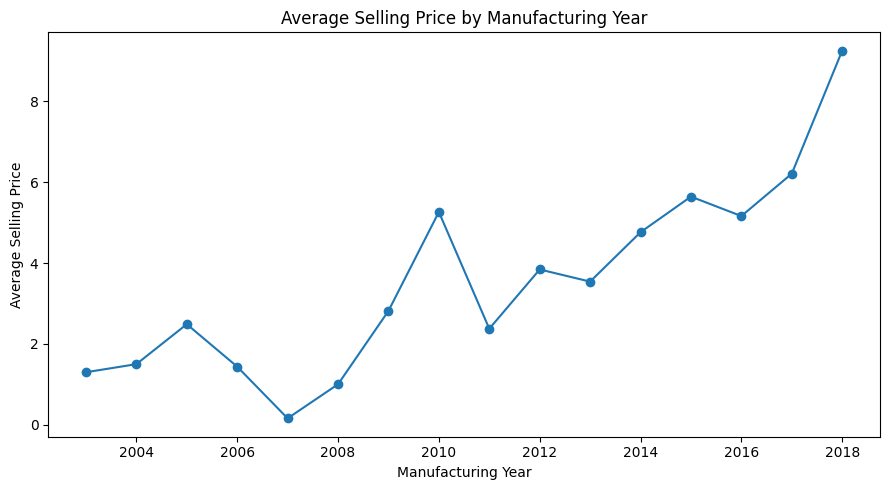

Correlation between Selling Price and Year: 0.234


In [5]:
year_avg = data.groupby("Year")["Selling_Price"].mean()

plt.figure(figsize=(9, 5))
plt.plot(year_avg.index, year_avg.values, marker="o")
plt.title("Average Selling Price by Manufacturing Year")
plt.xlabel("Manufacturing Year")
plt.ylabel("Average Selling Price")
plt.tight_layout()
plt.show()

print("Correlation between Selling Price and Year:",
      round(data["Selling_Price"].corr(data["Year"]), 3))

## 5. Fuel Type, Transmission & Seller Type

Fuel Type Summary


,count,mean,median
Fuel_Type,,,
Diesel,58,10.10,7.60
Petrol,239,3.26,2.65
CNG,2,3.10,3.10


Transmission Summary


,count,mean,median
Transmission,,,
Automatic,39,9.07,5.75
Manual,260,3.92,3.25


Seller Type Summary


,count,mean,median
Seller_Type,,,
Dealer,193,6.63,5.25
Individual,106,0.87,0.52


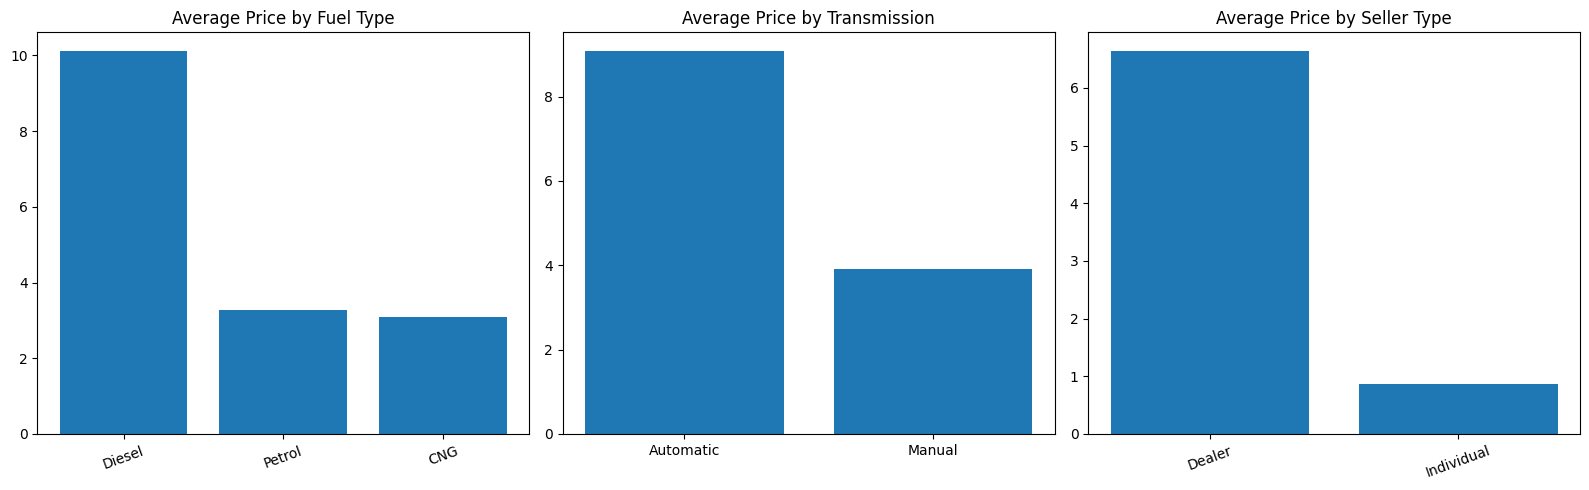

In [6]:
fuel_summary = data.groupby("Fuel_Type")["Selling_Price"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)
trans_summary = data.groupby("Transmission")["Selling_Price"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)
seller_summary = data.groupby("Seller_Type")["Selling_Price"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)

print("Fuel Type Summary")
display(fuel_summary)

print("Transmission Summary")
display(trans_summary)

print("Seller Type Summary")
display(seller_summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].bar(fuel_summary.index, fuel_summary["mean"])
axes[0].set_title("Average Price by Fuel Type")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(trans_summary.index, trans_summary["mean"])
axes[1].set_title("Average Price by Transmission")

axes[2].bar(seller_summary.index, seller_summary["mean"])
axes[2].set_title("Average Price by Seller Type")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 6. Kilometers Driven vs Selling Price

Correlation between Selling Price and Kms Driven: 0.029


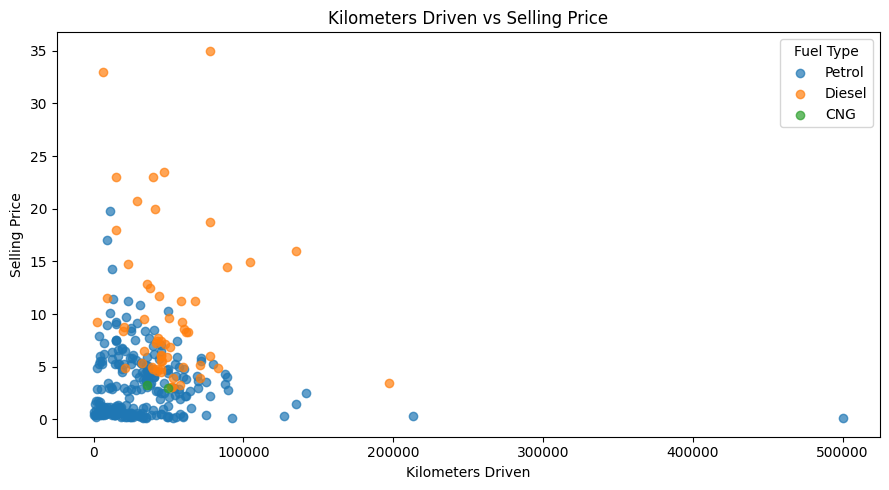

In [7]:
print("Correlation between Selling Price and Kms Driven:",
      round(data["Selling_Price"].corr(data["Kms_Driven"]), 3))

plt.figure(figsize=(9, 5))
for fuel in data["Fuel_Type"].unique():
    subset = data[data["Fuel_Type"] == fuel]
    plt.scatter(subset["Kms_Driven"], subset["Selling_Price"], label=fuel, alpha=0.7)
plt.title("Kilometers Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.legend(title="Fuel Type")
plt.tight_layout()
plt.show()

## 7. Car Age & Price Retention

,count,mean,median
Car_Age,,,
1,1,94.10,94.10
2,35,87.85,90.62
3,49,78.87,79.79
4,60,72.16,71.60
5,38,61.61,61.16
6,33,56.85,54.36
7,23,50.66,48.68
8,19,49.16,48.06
9,15,38.92,37.80


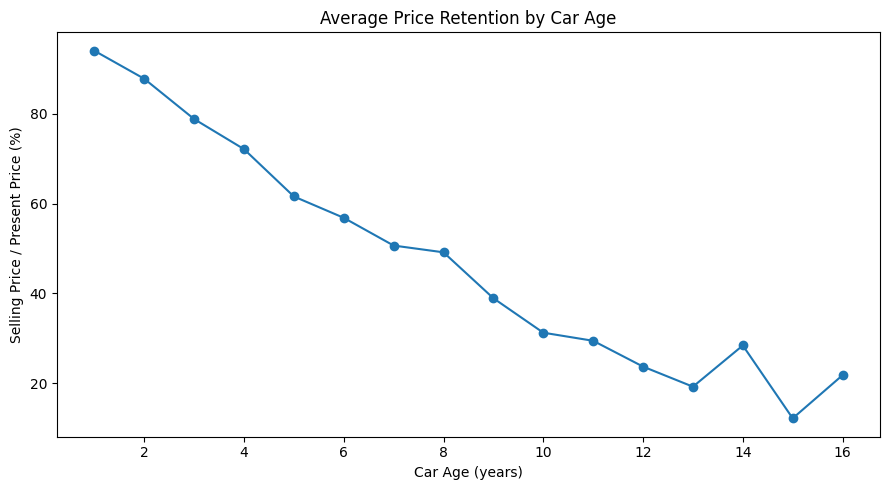

In [8]:
age_summary = data.groupby("Car_Age")["Price_Retention_%"].agg(["count", "mean", "median"])
display(age_summary)

plt.figure(figsize=(9, 5))
plt.plot(age_summary.index, age_summary["mean"], marker="o")
plt.title("Average Price Retention by Car Age")
plt.xlabel("Car Age (years)")
plt.ylabel("Selling Price / Present Price (%)")
plt.tight_layout()
plt.show()

## 8. Correlation Analysis

Correlation with Selling Price:


,correlation
Selling_Price,1.00
Present_Price,0.88
Year,0.23
Price_Retention_%,0.23
Kms_Driven,0.03
Owner,-0.09
Car_Age,-0.23


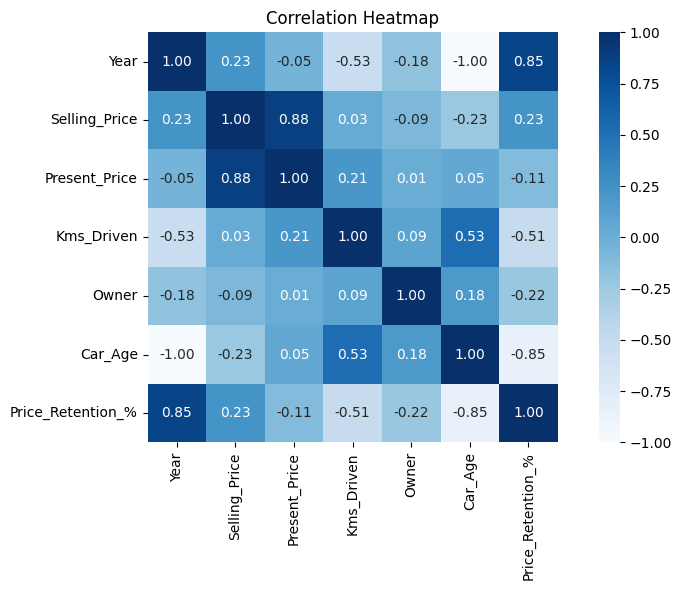

In [9]:
numeric_cols = [
    "Year", "Selling_Price", "Present_Price",
    "Kms_Driven", "Owner", "Car_Age", "Price_Retention_%"
]
corr = data[numeric_cols].corr()

print("Correlation with Selling Price:")
display(corr["Selling_Price"].sort_values(ascending=False).to_frame("correlation"))

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 9. Top Models by Average Selling Price

In [10]:
model_summary = (
    data.groupby("Car_Name")["Selling_Price"]
    .agg(["count", "mean", "median"])
    .query("count >= 2")
    .sort_values("mean", ascending=False)
)
display(model_summary.head(10))

,count,mean,median
Car_Name,,,
fortuner,10,18.25,17.38
innova,9,12.78,12.50
creta,3,11.80,11.25
elantra,2,11.60,11.60
ciaz,9,7.47,7.45
city,26,7.42,8.38
corolla altis,16,7.18,5.67
ertiga,5,6.58,6.10
verna,14,6.11,5.65


## 10. Key Business Insights

- The cleaned dataset contains **299 records** and **98 unique car names**.
- The supplied dataset has **0 missing values**.
- Exact duplicate rows identified before cleaning: **2**.
- Average selling price is **4.59**, while the median is **3.51**.
- Average kilometers driven is approximately **36,917**, with a median of **32,000**.
- Selling price has a **0.876** correlation with present price.
- Selling price has a **0.234** correlation with manufacturing year.
- Selling price has a **0.029** correlation with kilometers driven.
- The highest average-price fuel category is **Diesel** in this dataset.
- The higher average-price transmission category is **Automatic**.
- The higher average-price seller category is **Dealer**.

### Business Interpretation
These patterns can support price comparison, seller benchmarking and dealer inventory decisions. They are descriptive relationships; correlation does not prove that one variable causes another.

## 11. Conclusion

The analysis provides a structured view of used-car pricing using the supplied Car Dekho data. It combines data cleaning, feature engineering, descriptive statistics, categorical comparisons, relationship analysis and correlation analysis.

**Submitted By:** Onkar Abhiman Londhe 

**AICTE Student ID:** STU691884604e8cc1763214432